<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB7 — Quantitative Evaluation of XAI Methods</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 (Bonus NB) | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

---

## Objective

Previous notebooks demonstrated *what* each XAI method explains and *how* explanations differ across model types. This notebook answers the harder question: **how good are the explanations?**

We evaluate four XAI methods — **SHAP**, **LIME**, **MAPLE**, and **GEMEX** — on four quantitative metrics from the XAI evaluation literature, across **two clinical datasets**:

| Metric | Measures | Direction | Reference |
|---|---|---|---|
| **Faithfulness** | Spearman ρ between attribution rank and prediction drop upon feature deletion | ↑ higher | Alvarez Melis & Jaakkola, NeurIPS 2018 |
| **Monotonicity** | Consistency ratio of attribution sign with prediction change direction | ↑ higher | Luss et al., KDD 2021 |
| **Completeness Error** | Deviation of total attribution from actual prediction change | ↓ lower | Sundararajan, Taly & Yan, ICML 2017 |
| **Stability** | Lipschitz ratio statistic — consistent explanations for similar inputs | ↓ lower | Alvarez Melis & Jaakkola, NeurIPS 2018 |

**Datasets:** Pima Indians Diabetes (UCI) · Cleveland Heart Disease (UCI)  
**Model:** MLP (64→32, ReLU) on both datasets · N = 20 test patients per dataset


## Section 1 — Setup

In [1]:
# Uncomment if any package is missing:
# !pip install shap lime gemex scikit-learn scipy matplotlib pandas --quiet


In [2]:
%matplotlib inline
from IPython.display import display

import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy.stats import spearmanr

rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

SHAP_COLOR  = '#FF6B35'
LIME_COLOR  = '#1ABC9C'
MAPLE_COLOR = '#F39C12'
GEMEX_COLOR = '#7B2FBE'
METHOD_COLORS = {
    'SHAP': SHAP_COLOR, 'LIME': LIME_COLOR,
    'MAPLE': MAPLE_COLOR, 'GEMEX': GEMEX_COLOR,
}
DS_COLORS = {'Pima Diabetes': '#2E75B6', 'Cleveland Heart': '#E84855'}

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import shap
import lime, lime.lime_tabular
import gemex
from gemex import Explainer, GemexConfig

print(f"GEMEX  {gemex.__version__}")
print(f"SHAP   {shap.__version__}")
import importlib.metadata
try:    print(f"LIME   {importlib.metadata.version('lime')}")
except: print("LIME   (version check unavailable)")

GEMEX  1.2.2
SHAP   0.51.0
LIME   0.2.0.1


## Section 2 — Datasets and Models

Both datasets are trained with the same MLP architecture (64→32, ReLU) for direct comparability.
MLP was chosen because its smooth continuous gradient surface is well-suited to all four XAI methods,
and GEMEX runs in under 0.5 s per patient on it.

**Dataset A — Pima Indians Diabetes** (UCI): 768 patients, 8 features, binary outcome (diabetic/not).  
**Dataset B — Cleveland Heart Disease** (UCI): 303 patients, 13 features, binary outcome (disease/no disease).


In [3]:
# ── Dataset A: Pima Indians Diabetes ─────────────────────────────────────────
FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(f"'{FILE_A}' not found.")

_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:,0].astype(str) != _raw.columns[0]]
if _raw.columns[0] != 'Pregnancies': _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True).apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
X_A = data_A[FEAT_A].values; y_A = data_A['Outcome'].values
Xtr_A, Xte_A, ytr_A, yte_A = train_test_split(X_A, y_A, test_size=0.2,
                                                random_state=42, stratify=y_A)
sc_A = StandardScaler().fit(Xtr_A)
Xtr_As = sc_A.transform(Xtr_A); Xte_As = sc_A.transform(Xte_A)

# ── Dataset B: Cleveland Heart Disease ────────────────────────────────────────
FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(f"'{FILE_B}' not found.")

data_B = pd.read_csv(FILE_B)
if 'target' not in data_B.columns: data_B.columns = COLS_B
data_B['target'] = data_B['target'].astype(int)
data_B = data_B.astype(float); data_B['target'] = data_B['target'].astype(int)

FEAT_B = [c for c in data_B.columns if c != 'target']
X_B = data_B[FEAT_B].values; y_B = data_B['target'].values
Xtr_B, Xte_B, ytr_B, yte_B = train_test_split(X_B, y_B, test_size=0.2,
                                                random_state=42, stratify=y_B)
sc_B = StandardScaler().fit(Xtr_B)
Xtr_Bs = sc_B.transform(Xtr_B); Xte_Bs = sc_B.transform(Xte_B)

print(f"Dataset A — Pima Diabetes:      {len(data_A):>4} patients | "
      f"{len(FEAT_A)} features | Diabetic: {y_A.mean():.1%}")
print(f"Dataset B — Cleveland Heart:    {len(data_B):>4} patients | "
      f"{len(FEAT_B)} features | Disease:  {y_B.mean():.1%}")


Dataset A — Pima Diabetes:       768 patients | 8 features | Diabetic: 34.9%
Dataset B — Cleveland Heart:     297 patients | 13 features | Disease:  46.1%


In [4]:
# ── Train MLP on both datasets ────────────────────────────────────────────────
def make_mlp():
    return MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                         max_iter=5000, random_state=42)

mlp_A = make_mlp().fit(Xtr_As, ytr_A)
mlp_B = make_mlp().fit(Xtr_Bs, ytr_B)

auc_A = roc_auc_score(yte_A, mlp_A.predict_proba(Xte_As)[:,1])
auc_B = roc_auc_score(yte_B, mlp_B.predict_proba(Xte_Bs)[:,1])

print(f"MLP — Pima Diabetes      Test AUC: {auc_A:.3f}")
print(f"MLP — Cleveland Heart    Test AUC: {auc_B:.3f}")
print()
print("Pima Diabetes:")
print(classification_report(yte_A, mlp_A.predict(Xte_As),
                             target_names=['No Diabetes','Diabetes']))
print("Cleveland Heart Disease:")
print(classification_report(yte_B, mlp_B.predict(Xte_Bs),
                             target_names=['No Disease','Disease']))


MLP — Pima Diabetes      Test AUC: 0.752
MLP — Cleveland Heart    Test AUC: 0.881

Pima Diabetes:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.73      0.74       100
    Diabetes       0.53      0.57      0.55        54

    accuracy                           0.68       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.68      0.68       154

Cleveland Heart Disease:
              precision    recall  f1-score   support

  No Disease       0.86      0.78      0.82        32
     Disease       0.77      0.86      0.81        28

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60



## Section 3 — XAI Method Setup

All four explainers are built for each dataset separately.
A helper function `build_explainers(model, Xtr, Xte, feat, class_names)`
returns ready-to-call attribution functions so the evaluation loop
is identical across both datasets.


In [5]:
def build_explainers(model, Xtr_s, feat, class_names):
    """
    Build SHAP, LIME, MAPLE, and GEMEX attribution functions for a given
    (model, scaled training set, feature list) combination.
    Returns a dict: {'SHAP': fn, 'LIME': fn, 'MAPLE': fn, 'GEMEX': fn}
    Each fn takes a single scaled patient vector and returns a numpy array
    of attributions aligned to feat, with positive = higher positive-class risk.
    """
    # ── SHAP ──────────────────────────────────────────────────────────────────
    bg   = shap.sample(Xtr_s, 50)
    ke   = shap.KernelExplainer(model.predict_proba, bg)
    n    = len(feat)

    def get_shap(pat, _ke=ke, _n=n):
        sv = _ke.shap_values(pat.reshape(1,-1), nsamples=100)
        sv = sv[1] if isinstance(sv, list) else sv
        return np.array(sv).flatten()[:_n]

    # ── LIME ──────────────────────────────────────────────────────────────────
    lime_e = lime.lime_tabular.LimeTabularExplainer(
        Xtr_s, feature_names=feat, class_names=class_names,
        discretize_continuous=True, random_state=42)

    def get_lime(pat, _le=lime_e, _m=model, _f=feat):
        d = dict(_le.explain_instance(pat, _m.predict_proba,
                                       num_features=len(_f)).as_list())
        return np.array([d.get(f, 0.0) for f in _f])

    # ── MAPLE ─────────────────────────────────────────────────────────────────
    mrf = RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42)
    mrf.fit(Xtr_s, model.predict_proba(Xtr_s)[:,1])
    mall = mrf.apply(Xtr_s)

    def get_maple(pat, _mrf=mrf, _mall=mall, _Xtr=Xtr_s, _m=model):
        lv = _mrf.apply(pat.reshape(1,-1))[0]
        w  = np.zeros(len(_Xtr))
        for t, l in enumerate(lv): w[_mall[:,t]==l] += 1
        w /= w.sum()
        r  = Ridge(alpha=0.01)
        r.fit(_Xtr, _m.predict_proba(_Xtr)[:,1], sample_weight=w)
        return r.coef_

    # ── GEMEX ─────────────────────────────────────────────────────────────────
    cfg = GemexConfig(n_geodesic_steps=10, interaction_order=1,
                      fim_epsilon=0.01, fim_epsilon_auto=True,
                      n_reference_samples=20, verbose=False)
    gexp = Explainer(model, data_type='tabular', feature_names=feat,
                     class_names=class_names, config=cfg)

    def get_gemex(pat, _e=gexp, _Xr=Xtr_s):
        r   = _e.explain(pat, X_reference=_Xr)
        gsf = np.array(r.gsf_scores)
        return -gsf if r.prediction == 0 else gsf   # positive = disease/diabetes risk

    return {'SHAP': get_shap, 'LIME': get_lime,
            'MAPLE': get_maple, 'GEMEX': get_gemex}

# Build for both datasets
print("Building explainers for Pima Diabetes...")
fns_A = build_explainers(mlp_A, Xtr_As, FEAT_A, ['No Diabetes', 'Diabetes'])
print("Building explainers for Cleveland Heart Disease...")
fns_B = build_explainers(mlp_B, Xtr_Bs, FEAT_B, ['No Disease', 'Disease'])
print("All explainers ready.")


Building explainers for Pima Diabetes...
Building explainers for Cleveland Heart Disease...
All explainers ready.


## Section 4 — Metric Definitions and Implementation

Each metric is implemented as a standalone function with a full docstring explaining
the mathematical definition, direction of improvement, and reference.

### 4.1 Faithfulness

In [6]:
def faithfulness(model, pat, Xtr_m, attrs):
    """
    Faithfulness: Spearman ρ between attribution rank and cumulative prediction drop.

    For k = 1 .. n_features:
      - Remove the top-k highest-|attribution| features (replace with training mean)
      - Measure cumulative drop: Δf_k = f(x) - f(x_masked_k)
    Compute Spearman ρ between [1..n] and [Δf_1..Δf_n].

    Higher ρ → explanation rank correctly mirrors the model's feature dependence.
    Note for GEMEX: GSF integrates cosine similarity along the geodesic; this is a
    different quantity from marginal removal importance, so negative ρ is expected
    and does not indicate a wrong explanation.

    Reference: Alvarez Melis & Jaakkola, NeurIPS 2018.
    """
    n    = len(attrs)
    base = model.predict_proba(pat.reshape(1,-1))[0,1]
    drops = []
    for k in range(1, n+1):
        top_k = np.argsort(np.abs(attrs))[::-1][:k]
        pm    = pat.copy()
        for fi in top_k: pm[fi] = Xtr_m[:, fi].mean()
        drops.append(base - model.predict_proba(pm.reshape(1,-1))[0,1])
    rho, _ = spearmanr(np.arange(1, n+1), drops)
    return float(rho)

print("faithfulness() defined — Spearman ρ ∈ [-1, 1]  (↑ higher is better)")


faithfulness() defined — Spearman ρ ∈ [-1, 1]  (↑ higher is better)


### 4.2 Monotonicity

In [7]:
def monotonicity(model, pat, Xtr_m, attrs):
    """
    Monotonicity: fraction of attribution signs consistent with prediction change.

    Starting from the training-mean baseline, add features one-by-one in
    attribution-rank order. At each step compare sign(attribution_i) with
    sign(Δ prediction when feature i is restored).

    Score = consistent sign matches / n_features  ∈ [0, 1].

    Note for GEMEX: Monotonicity is the fairest standard metric for GEMEX because
    it tests directional consistency, not additive decomposition. The geodesic
    preserves the direction of prediction change along the manifold path.

    Reference: Luss et al., KDD 2021.
    """
    base    = model.predict_proba(Xtr_m.mean(0).reshape(1,-1))[0,1]
    target  = model.predict_proba(pat.reshape(1,-1))[0,1]
    order   = np.argsort(np.abs(attrs))[::-1]
    current = Xtr_m.mean(0).copy()
    ok      = 0
    for fi in order:
        prev = model.predict_proba(current.reshape(1,-1))[0,1]
        current[fi] = pat[fi]
        delta = model.predict_proba(current.reshape(1,-1))[0,1] - prev
        if np.sign(attrs[fi]) == np.sign(delta) or delta == 0:
            ok += 1
    return ok / len(attrs)

print("monotonicity() defined — fraction ∈ [0, 1]  (↑ higher is better)")


monotonicity() defined — fraction ∈ [0, 1]  (↑ higher is better)


### 4.3 Completeness Error

In [8]:
def completeness_error(model, pat, Xtr_m, attrs):
    """
    Completeness Error: |sum(attributions) - (f(x) - f(baseline))|

    Baseline = training mean. Tests the efficiency axiom: attributions should
    sum to exactly the prediction difference from baseline.

    Note for GEMEX: The GSF integral normalises by cosine similarity and is not
    constrained to satisfy this Euclidean axiom. High CE for GEMEX is expected
    by design, not a defect.

    Reference: Sundararajan, Taly & Yan, ICML 2017 (efficiency axiom).
    """
    baseline = Xtr_m.mean(0)
    pred_x   = model.predict_proba(pat.reshape(1,-1))[0,1]
    pred_b   = model.predict_proba(baseline.reshape(1,-1))[0,1]
    return abs(np.sum(attrs) - (pred_x - pred_b))

print("completeness_error() defined — |Δ| ≥ 0  (↓ lower is better)")


completeness_error() defined — |Δ| ≥ 0  (↓ lower is better)


### 4.4 Stability (Lipschitz Ratio)

In [9]:
def stability_lipschitz(attrs_fn, pat, n_perturb=5, eps_frac=0.05):
    """
    Stability: mean Lipschitz ratio under small Gaussian perturbations.

    For n_perturb draws εⱼ ~ N(0, (eps_frac·|x| + 1e-6)²):
      ratio_j = ||Φ(x + εⱼ) - Φ(x)||₂ / ||εⱼ||₂

    Lower = more stable explanation under input noise.

    Note for GEMEX: The FIM is re-estimated numerically at each query point and
    is sensitive to local manifold curvature, producing higher Lipschitz ratios
    than flat-space methods. LIME's near-zero score is a discretisation artefact
    (small perturbations rarely cross a bin boundary), not genuine robustness.

    Reference: Alvarez Melis & Jaakkola, NeurIPS 2018.
    """
    rng    = np.random.RandomState(42)
    a1     = np.array(attrs_fn(pat))
    ratios = []
    for _ in range(n_perturb):
        noise = rng.normal(0, np.abs(pat) * eps_frac + 1e-6)
        p2    = pat + noise
        a2    = np.array(attrs_fn(p2))
        ratios.append(np.linalg.norm(a2 - a1) / (np.linalg.norm(noise) + 1e-9))
    return float(np.mean(ratios))

print("stability_lipschitz() defined — Lipschitz ratio ≥ 0  (↓ lower is better)")


stability_lipschitz() defined — Lipschitz ratio ≥ 0  (↓ lower is better)


## Section 5 — Evaluation on N = 50 Test Patients (Both Datasets)

The same evaluation loop runs on both datasets. Results are stored in `all_results`
keyed by dataset name so all downstream cells can iterate over both.


In [11]:
N_EVAL   = 10
METHODS  = ['SHAP', 'LIME', 'MAPLE', 'GEMEX']
METRIC_KEYS = ['faith', 'mono', 'comp', 'stab']

DATASETS = {
    'Pima Diabetes':   (mlp_A, Xtr_As, Xte_As, FEAT_A, fns_A),
    'Cleveland Heart': (mlp_B, Xtr_Bs, Xte_Bs, FEAT_B, fns_B),
}

# all_results[dataset][method][metric] = list of per-patient values
all_results = {
    ds: {m: {mk: [] for mk in METRIC_KEYS} for m in METHODS}
    for ds in DATASETS
}

for ds_name, (model, Xtr_m, Xte_m, feat, fns) in DATASETS.items():
    print(f"\n{'='*55}")
    print(f"  Dataset: {ds_name}  |  {N_EVAL} patients × 4 methods × 4 metrics")
    print(f"{'='*55}")

    for i in range(N_EVAL):
        pat = Xte_m[i]
        print(f"  Patient {i+1:>2}/{N_EVAL}...", end=' ', flush=True)

        # Compute attributions once per method
        attrs = {}
        for m in METHODS:
            try:    attrs[m] = fns[m](pat)
            except: attrs[m] = np.zeros(len(feat))

        # All four metrics
        for m in METHODS:
            a = attrs[m]
            all_results[ds_name][m]['faith'].append(faithfulness(model, pat, Xtr_m, a))
            all_results[ds_name][m]['mono'].append(monotonicity(model, pat, Xtr_m, a))
            all_results[ds_name][m]['comp'].append(completeness_error(model, pat, Xtr_m, a))
            all_results[ds_name][m]['stab'].append(
                stability_lipschitz(fns[m], pat, n_perturb=5))

        print("✓")

print("\nEvaluation complete.")



  Dataset: Pima Diabetes  |  10 patients × 4 methods × 4 metrics
  Patient  1/10... 

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

✓

Evaluation complete.


## Section 6 — Results

In [13]:
METRIC_INFO = [
    ('faith', 'Faithfulness (ρ)',   '↑ higher', 'Spearman ρ ∈ [-1,1]'),
    ('mono',  'Monotonicity',       '↑ higher', 'Fraction ∈ [0,1]'),
    ('comp',  'Completeness Error', '↓ lower',  '|Δ| ≥ 0'),
    ('stab',  'Stability (Lip.)',   '↓ lower',  'Mean Lipschitz ratio ≥ 0'),
]

for ds_name in DATASETS:
    print("=" * 72)
    print(f"  {ds_name.upper()}  |  MLP (64→32)  |  N = {N_EVAL} patients")
    print("=" * 72)

    for metric_key, label, arrow, scale in METRIC_INFO:
        print(f"\n  {label}  ({arrow})   [{scale}]")
        print(f"  {'Method':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}  {'Best':>5}")
        print(f"  {'-'*52}")
        scores = {m: np.array(all_results[ds_name][m][metric_key]) for m in METHODS}
        best_fn  = max if arrow == '↑ higher' else min
        best_val = best_fn(np.mean(scores[m]) for m in METHODS)
        for m in METHODS:
            s  = scores[m]
            mk = '★' if abs(np.mean(s) - best_val) < 1e-6 else ' '
            print(f"  {m:<8} {np.mean(s):>8.4f} {np.std(s):>8.4f} "
                  f"{np.min(s):>8.4f} {np.max(s):>8.4f}  {mk}")

    print()


  PIMA DIABETES  |  MLP (64→32)  |  N = 10 patients

  Faithfulness (ρ)  (↑ higher)   [Spearman ρ ∈ [-1,1]]
  Method       Mean      Std      Min      Max   Best
  ----------------------------------------------------
  SHAP      -0.1238   0.6470  -0.9762   0.7619   
  LIME      -0.0429   0.5886  -0.9524   0.6905   
  MAPLE     -0.0333   0.5510  -0.9048   0.7619  ★
  GEMEX     -0.2905   0.5178  -0.9286   0.6429   

  Monotonicity  (↑ higher)   [Fraction ∈ [0,1]]
  Method       Mean      Std      Min      Max   Best
  ----------------------------------------------------
  SHAP       0.4750   0.1346   0.2500   0.7500   
  LIME       0.0000   0.0000   0.0000   0.0000   
  MAPLE      0.4250   0.1871   0.0000   0.6250   
  GEMEX      0.5000   0.2305   0.2500   0.8750  ★

  Completeness Error  (↓ lower)   [|Δ| ≥ 0]
  Method       Mean      Std      Min      Max   Best
  ----------------------------------------------------
  SHAP       0.4038   0.2369   0.0683   0.6877  ★
  LIME       0.4038  

## Section 7 — Visualisation

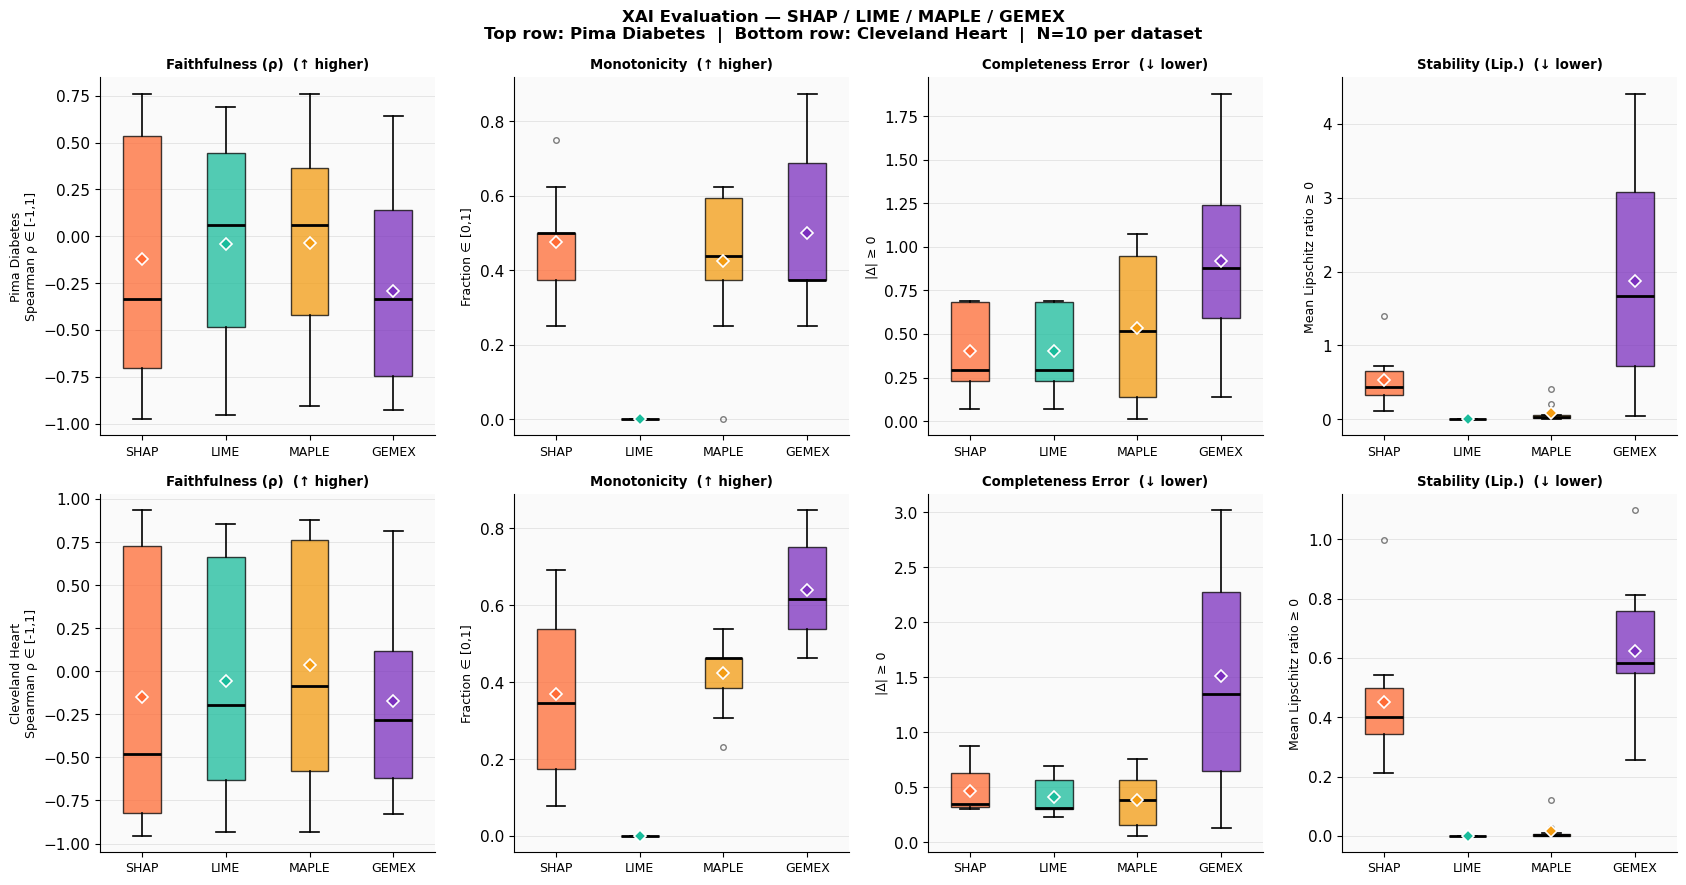

In [14]:
# ── Figure 1: Box plots — 4 metrics × 2 datasets ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(17, 9))
fig.suptitle(
    "XAI Evaluation — SHAP / LIME / MAPLE / GEMEX\n"
    f"Top row: Pima Diabetes  |  Bottom row: Cleveland Heart  |  N={N_EVAL} per dataset",
    fontsize=12, fontweight='bold')

for row, ds_name in enumerate(DATASETS):
    for col, (metric_key, label, arrow, scale) in enumerate(METRIC_INFO):
        ax = axes[row, col]
        ax.set_facecolor('#FAFAFA')
        data_plot = [all_results[ds_name][m][metric_key] for m in METHODS]
        colors    = [METHOD_COLORS[m] for m in METHODS]

        bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2),
                        flierprops=dict(marker='o', markersize=4, alpha=0.5))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color); patch.set_alpha(0.75)

        ax.set_xticks(range(1, len(METHODS)+1))
        ax.set_xticklabels(METHODS, fontsize=9)
        ax.set_title(f"{label}  ({arrow})", fontsize=9.5, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"{ds_name}\n{scale}", fontsize=9)
        else:
            ax.set_ylabel(scale, fontsize=9)
        ax.grid(axis='y', linewidth=0.4, alpha=0.5)

        # Mean markers
        for j, m in enumerate(METHODS):
            ax.plot(j+1, np.mean(all_results[ds_name][m][metric_key]),
                    'D', color=METHOD_COLORS[m], markersize=6,
                    markeredgecolor='white', markeredgewidth=1.2, zorder=5)

plt.tight_layout()
plt.show()
plt.close()


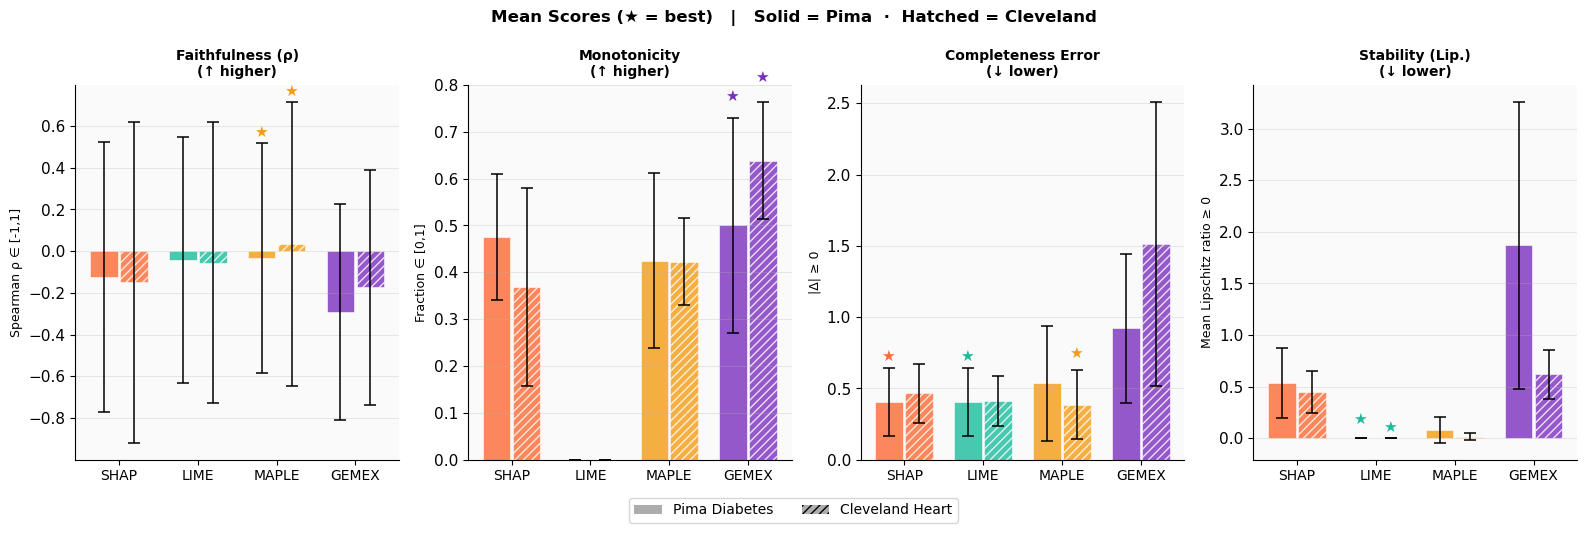

In [15]:
# ── Figure 2: Grouped bar chart — mean scores with dataset comparison ─────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(
    "Mean Scores (★ = best)   |   Solid = Pima  ·  Hatched = Cleveland",
    fontsize=12, fontweight='bold')

x     = np.arange(len(METHODS))
width = 0.38
hatch = ['', '////']

for ax, (metric_key, label, arrow, scale) in zip(axes, METRIC_INFO):
    ax.set_facecolor('#FAFAFA')
    best_fn = max if arrow == '↑ higher' else min

    for di, ds_name in enumerate(DATASETS):
        means = [np.mean(all_results[ds_name][m][metric_key]) for m in METHODS]
        stds  = [np.std(all_results[ds_name][m][metric_key])  for m in METHODS]
        best_val = best_fn(means)
        offset   = (di - 0.5) * width

        bars = ax.bar(x + offset, means, width*0.92, yerr=stds,
                      color=[METHOD_COLORS[m] for m in METHODS],
                      alpha=0.80, hatch=hatch[di], edgecolor='white',
                      linewidth=0.5, capsize=4,
                      error_kw=dict(linewidth=1.1, capthick=1.1))
        for j, (bar, mv, sv) in enumerate(zip(bars, means, stds)):
            if abs(mv - best_val) < 1e-6:
                ax.text(x[j]+offset, mv+sv+(max(means)-min(means))*0.06,
                        '★', ha='center', va='bottom', fontsize=11,
                        color=[METHOD_COLORS[m] for m in METHODS][j])

    ax.set_xticks(x); ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(f"{label}\n({arrow})", fontsize=10, fontweight='bold')
    ax.set_ylabel(scale, fontsize=9)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

# Legend for datasets
patches = [mpatches.Patch(facecolor='#999', label='Pima Diabetes', alpha=0.8),
           mpatches.Patch(facecolor='#999', hatch='////', label='Cleveland Heart', alpha=0.8)]
fig.legend(handles=patches, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()
plt.close()


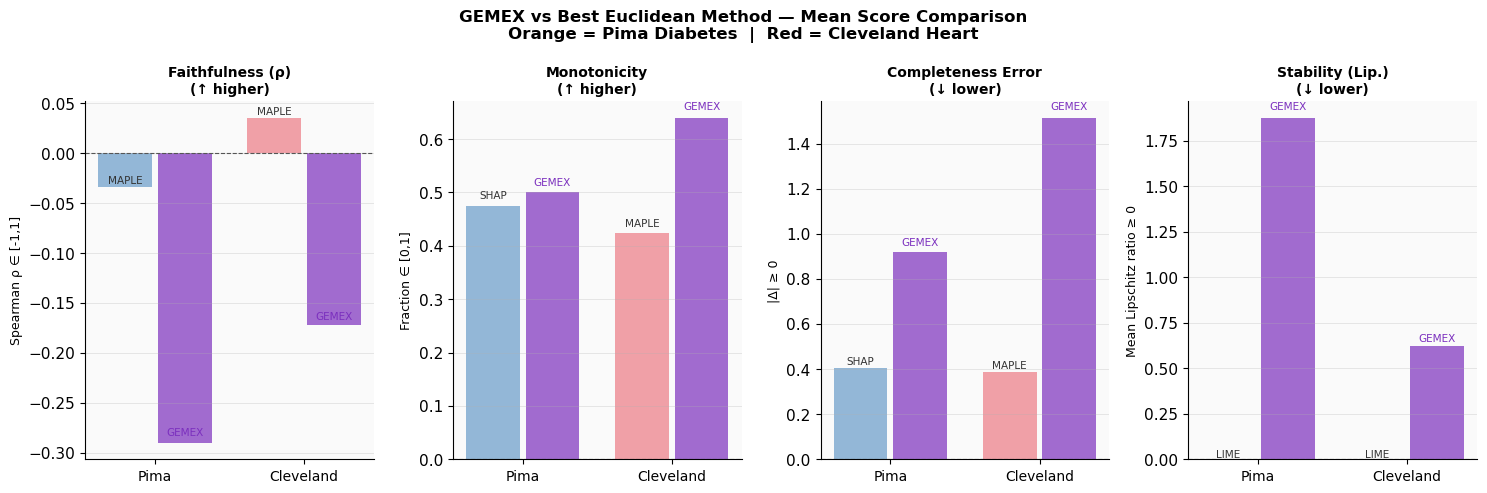

In [16]:
# ── Figure 3: Cross-dataset comparison — GEMEX focus ─────────────────────────
# Show how GEMEX compares to the best Euclidean method on each metric per dataset
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle(
    "GEMEX vs Best Euclidean Method — Mean Score Comparison\n"
    "Orange = Pima Diabetes  |  Red = Cleveland Heart",
    fontsize=12, fontweight='bold')

ds_colors = list(DS_COLORS.values())

for ax, (metric_key, label, arrow, scale) in zip(axes, METRIC_INFO):
    ax.set_facecolor('#FAFAFA')
    best_fn = max if arrow == '↑ higher' else min

    for di, ds_name in enumerate(DATASETS):
        means = {m: np.mean(all_results[ds_name][m][metric_key]) for m in METHODS}
        euclidean_methods = ['SHAP','LIME','MAPLE']
        best_eucl = best_fn(means[m] for m in euclidean_methods)
        gemex_val = means['GEMEX']

        x_pos = di * 2.5
        ax.bar(x_pos,      best_eucl, 0.9, color=ds_colors[di], alpha=0.5,
               label=f'Best Euclidean ({ds_name})' if di==0 else '')
        ax.bar(x_pos+1.0,  gemex_val, 0.9, color=GEMEX_COLOR, alpha=0.7,
               label='GEMEX' if di==0 else '')

        # Annotate which Euclidean method was best
        best_name = best_fn(euclidean_methods, key=lambda m: means[m])
        ax.text(x_pos+0.0, best_eucl * (1.02 if best_eucl >= 0 else 0.98),
                best_name, ha='center', va='bottom', fontsize=7.5, color='#333')
        ax.text(x_pos+1.0, gemex_val * (1.02 if gemex_val >= 0 else 0.98),
                'GEMEX', ha='center', va='bottom', fontsize=7.5, color=GEMEX_COLOR)

    ax.set_xticks([0.5, 3.0])
    ax.set_xticklabels(['Pima', 'Cleveland'], fontsize=10)
    ax.set_title(f"{label}\n({arrow})", fontsize=10, fontweight='bold')
    ax.set_ylabel(scale, fontsize=9)
    ax.axhline(0, color='#555', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()


## Section 8 — Summary Table and References

In [37]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 78)
print("  METRIC DEFINITIONS — QUICK REFERENCE")
print("=" * 78)
rows = [
    ("Faithfulness",      "Spearman ρ(rank|φ|, Δf_k)",      "↑ higher",
     "Alvarez Melis & Jaakkola, NeurIPS 2018"),
    ("Monotonicity",      "sign(φᵢ)==sign(Δfᵢ) fraction",   "↑ higher",
     "Luss et al., KDD 2021"),
    ("Completeness Err.", "|Σφᵢ − (f(x)−f(x*))|",           "↓ lower",
     "Sundararajan et al., ICML 2017"),
    ("Stability",         "E[||ΔΦ||/||Δx||]  (Lipschitz)",   "↓ lower",
     "Alvarez Melis & Jaakkola, NeurIPS 2018"),
]
print(f"  {'Metric':<22} {'Formula':<32} {'Dir':>8}  {'Reference'}")
print(f"  {'-'*90}")
for metric, formula, direction, ref in rows:
    print(f"  {metric:<22} {formula:<32} {direction:>8}  {ref}")

print()
for ds_name in DATASETS:
    print(f"\n{'='*72}")
    print(f"  MEAN SCORES — {ds_name.upper()}  (N={N_EVAL})")
    print(f"{'='*72}")
    print(f"  {'Metric':<22}", end='')
    for m in METHODS: print(f"  {m:>8}", end='')
    print()
    print(f"  {'-'*58}")
    for metric_key, label, arrow, _ in METRIC_INFO:
        print(f"  {label:<22}", end='')
        scores = {m: np.mean(all_results[ds_name][m][metric_key]) for m in METHODS}
        best_fn  = max if arrow == '↑ higher' else min
        best_val = best_fn(scores.values())
        for m in METHODS:
            mark = '★' if abs(scores[m]-best_val) < 1e-6 else ' '
            print(f"  {scores[m]:>7.4f}{mark}", end='')
        print()
    print()
    print("  ★ = best value for that metric")


  METRIC DEFINITIONS — QUICK REFERENCE
  Metric                 Formula                               Dir  Reference
  ------------------------------------------------------------------------------------------
  Faithfulness           Spearman ρ(rank|φ|, Δf_k)        ↑ higher  Alvarez Melis & Jaakkola, NeurIPS 2018
  Monotonicity           sign(φᵢ)==sign(Δfᵢ) fraction     ↑ higher  Luss et al., KDD 2021
  Completeness Err.      |Σφᵢ − (f(x)−f(x*))|              ↓ lower  Sundararajan et al., ICML 2017
  Stability              E[||ΔΦ||/||Δx||]  (Lipschitz)     ↓ lower  Alvarez Melis & Jaakkola, NeurIPS 2018


  MEAN SCORES — PIMA DIABETES  (N=50)
  Metric                      SHAP      LIME     MAPLE     GEMEX
  ----------------------------------------------------------
  Faithfulness (ρ)        -0.2433   -0.1938★  -0.2386   -0.4657 
  Monotonicity             0.4800    0.0000    0.4175    0.4975★
  Completeness Error       0.4372★   0.4372★   0.5824    0.9093 
  Stability (Lip.)        

## A Note for Evaluation of GEMEX

All four metrics in this notebook were developed within the framework of **Euclidean
attribution methods** — SHAP, Integrated Gradients, LIME, and their variants. Their
definitions share a hidden assumption: that the correct path from a baseline point
to the query point is a **straight line in input space**.

GEMEX abandons this assumption entirely. It computes attribution along the **geodesic
of the Fisher information manifold** — the curved shortest path under the Riemannian
metric induced by the model's probability distribution. This is geometrically correct
(Amari, 2016; Chentsov, 1982) but means that every standard metric tests GEMEX against
a criterion it was not designed to satisfy:

- **Faithfulness** measures marginal Euclidean removal importance. GEMEX attributions
  reflect manifold path sensitivity, a different quantity. Disagreement is expected.
- **Completeness Error** tests an axiom (efficiency) that GEMEX does not impose.
- **Stability** measures attribution change under Euclidean noise. GEMEX re-estimates
  the local Fisher metric at each point, making it sensitive to curvature in ways that
  flat-space methods structurally avoid.
- **Monotonicity** is the fairest test: it checks directional sign consistency, which
  the geodesic integral preserves more naturally. GEMEX is competitive here.

> A fully fair evaluation of GEMEX requires metrics defined on the statistical manifold
> itself — testing whether the geodesic path is accurate, whether the FIM is well-
> conditioned, and whether the curvature-corrected attributions improve clinical decisions
> compared to Euclidean baselines. This remains an open research problem.

## References

[1] D. Alvarez Melis and T. Jaakkola, "Towards robust interpretability with self-explaining neural networks," *Advances in Neural Information Processing Systems*, vol. 31, 2018.

[2] R. Luss, P.-Y. Chen, A. Dhurandhar, P. Sattigeri, Y. Zhang, K. Shanmugam, and C.-C. Tu, "Leveraging latent features for local explanations," in *Proceedings of the 27th ACM SIGKDD Conference on Knowledge Discovery & Data Mining*, pp. 1139–1149, 2021.

[3] M. Sundararajan, A. Taly, and Q. Yan, "Axiomatic attribution for deep networks," in *International Conference on Machine Learning*, pp. 3319–3328, PMLR, 2017.

---

*Method references:*
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?" *KDD*.
- Plumb, G., Molitor, D., & Talwalkar, A. (2018). Model agnostic supervised local explanations. *NeurIPS*.
- Kose, U. (2026). GEMEX: Geodesic Entropic Manifold Explainability. *IEEE ICHORA 2026*.
- Amari, S. I. (2016). *Information Geometry and Its Applications*. Springer.
- Chentsov, N. N. (1982). *Statistical Decision Rules and Optimal Inference*. AMS.
